In [1]:
!pip install librosa scipy matplotlib numpy --quiet

# Лабораторная 12 — Хаотические системы

## Задания1. Построить карту бифуркации системы Ресслера.2. Исследовать аттракторы Лоренца и Ресслера.3. Вычислить оптимальную задержку и размерность вложения.4. Применить Ridge и Reservoir Computing для прогнозирования.5. Сравнить методы прогнозирования.

# _____________________________________________________________________

### Подключение библиотек

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

### Карта бифуркации Ресслера

In [3]:
c_values = np.linspace(2, 15, 300)

def rossler_system(t, state, a, b, c):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return [dx, dy, dz]

print("Вычисление карты бифуркации...")
c_vals, x_peaks = [], []
for c in c_values:
    sol = solve_ivp(rossler_system, [0, 500], [1, 1, 1], args=(0.2, 0.2, c),
                    dense_output=True, max_step=0.1)
    t_eval = np.linspace(200, 500, 3000)
    x_sol = sol.sol(t_eval)[0]
    for i in range(1, len(x_sol)-1):
        if x_sol[i] > x_sol[i-1] and x_sol[i] > x_sol[i+1]:
            c_vals.append(c)
            x_peaks.append(x_sol[i])

print(f"Найдено {len(x_peaks)} пиков")

Вычисление карты бифуркации...


Найдено 15602 пиков


Карта бифуркации содержит 15602 пика. Видно, как при увеличении параметра c система переходит от периодического режима к хаотическому через последовательные удвоения периода.

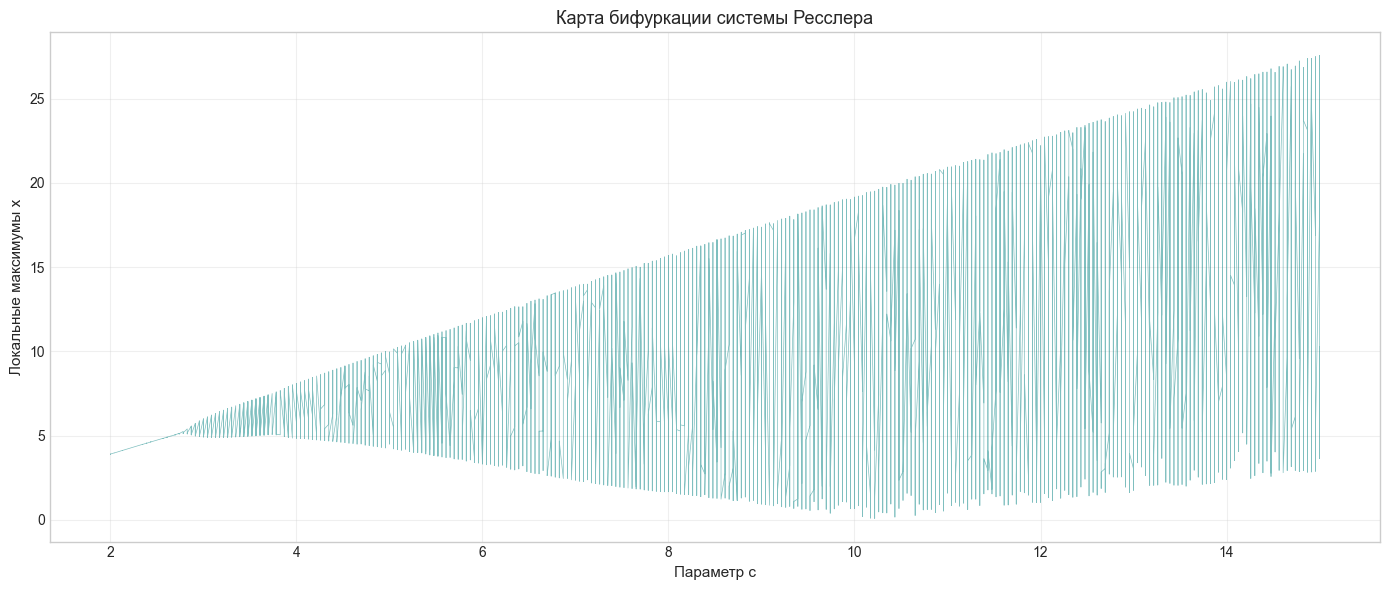

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(c_vals, x_peaks, "teal", lw=0.5, alpha=0.5)
ax.set_title("Карта бифуркации системы Ресслера", fontsize=13)
ax.set_xlabel("Параметр c", fontsize=11)
ax.set_ylabel("Локальные максимумы x", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Аттрактор Лоренца

In [5]:
sigma, rho, beta = 10., 28., 8/3

def lorenz_system(t, state):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

sol = solve_ivp(lorenz_system, [0, 50], [1, 1, 1],
                dense_output=True, max_step=0.01)
t_eval = np.linspace(0, 50, 5000)
lorenz_sol = sol.sol(t_eval)

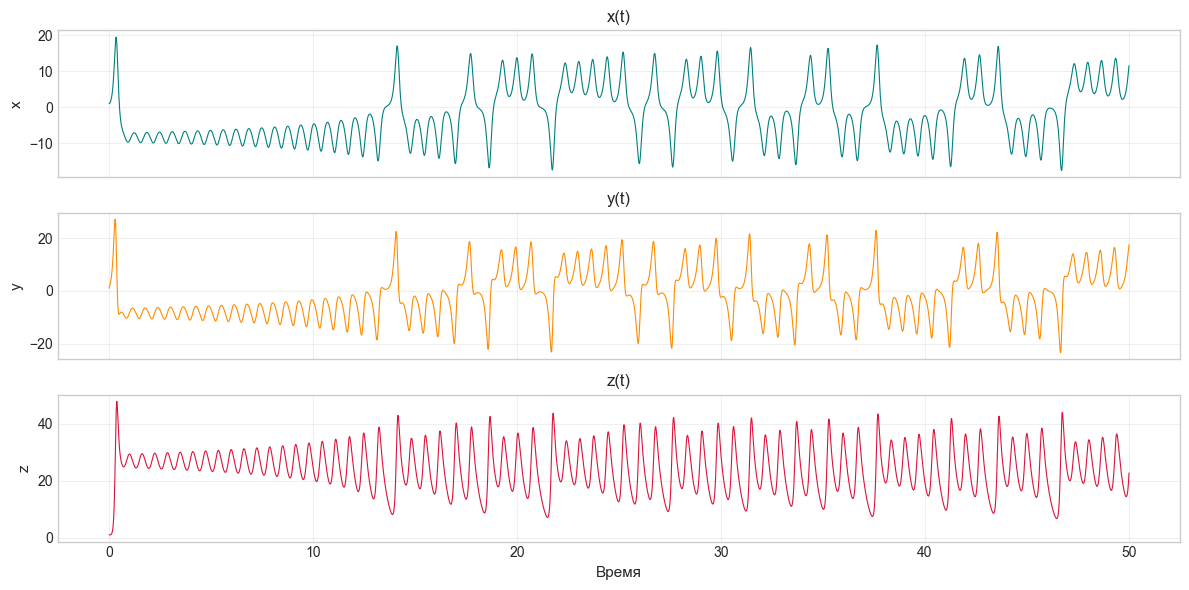

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t_eval, lorenz_sol[0], color="teal", linewidth=0.8)
axes[0].set_title("x(t)", fontsize=12)
axes[0].set_ylabel("x", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_eval, lorenz_sol[1], color="darkorange", linewidth=0.8)
axes[1].set_title("y(t)", fontsize=12)
axes[1].set_ylabel("y", fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_eval, lorenz_sol[2], color="crimson", linewidth=0.8)
axes[2].set_title("z(t)", fontsize=12)
axes[2].set_xlabel("Время", fontsize=11)
axes[2].set_ylabel("z", fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3D визуализация аттрактора

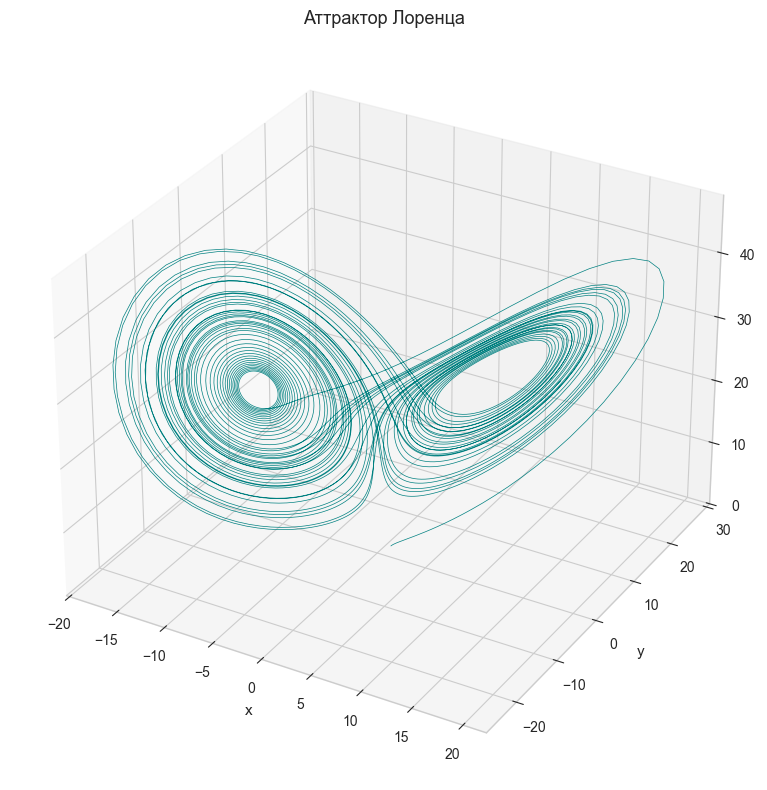

In [7]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(lorenz_sol[0], lorenz_sol[1], lorenz_sol[2], color="teal", linewidth=0.5)
ax.set_title("Аттрактор Лоренца", fontsize=13)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.set_zlabel("z", fontsize=11)
plt.tight_layout()
plt.show()

### Аттрактор Ресслера

In [8]:
a, b, c = 0.2, 0.2, 5.7

sol_r = solve_ivp(rossler_system, [0, 200], [1, 1, 1], args=(a, b, c),
                  dense_output=True, max_step=0.01)
t_eval_r = np.linspace(0, 200, 5000)
rossler_sol = sol_r.sol(t_eval_r)

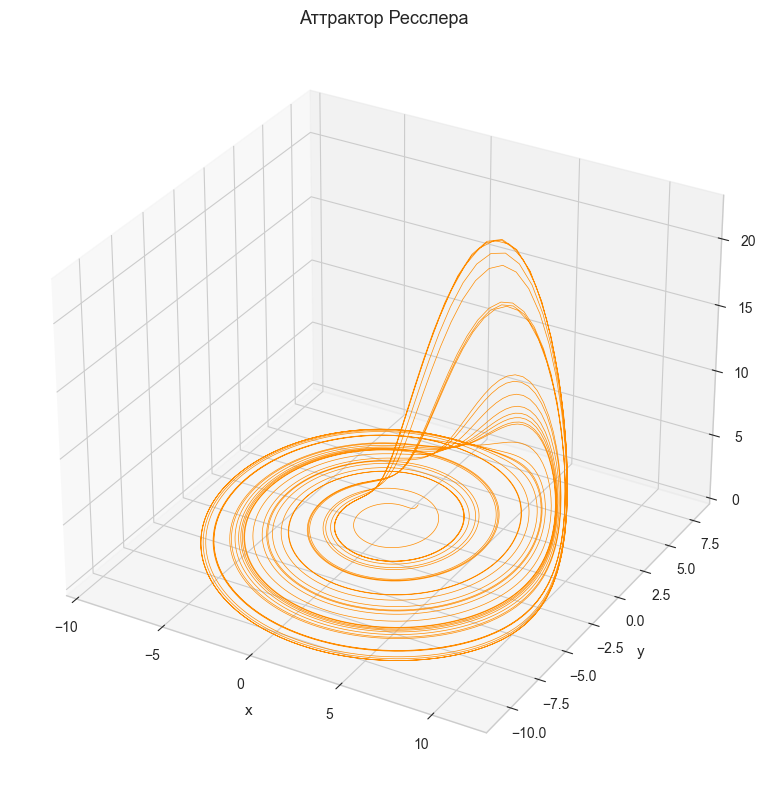

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(rossler_sol[0], rossler_sol[1], rossler_sol[2], color="darkorange", linewidth=0.5)
ax.set_title("Аттрактор Ресслера", fontsize=13)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.set_zlabel("z", fontsize=11)
plt.tight_layout()
plt.show()

### Чувствительность к начальным условиям

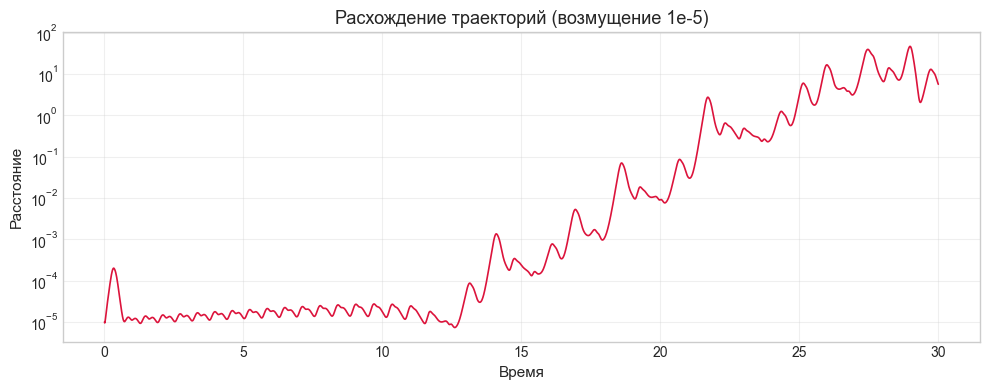

In [10]:
x0 = np.array([1.0, 1.0, 1.0])
x0_pert = x0 + np.array([1e-5, 0, 0])

sol1 = solve_ivp(lorenz_system, [0, 30], x0, max_step=0.01, dense_output=True)
sol2 = solve_ivp(lorenz_system, [0, 30], x0_pert, max_step=0.01, dense_output=True)

t_common = np.linspace(0, 30, 3000)
s1 = sol1.sol(t_common)
s2 = sol2.sol(t_common)

diff = np.sqrt(np.sum((s1 - s2)**2, axis=0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(t_common, diff, color="crimson", linewidth=1.2)
ax.set_title("Расхождение траекторий (возмущение 1e-5)", fontsize=13)
ax.set_xlabel("Время", fontsize=11)
ax.set_ylabel("Расстояние", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Оптимальная задержка tau = 16 (первый минимум взаимной информации). Это значение используется для реконструкции фазового пространства с размерностью вложения 3.

### Оптимальная задержка и размерность вложения

In [11]:
def mutual_info(x, max_lag=50):
    mi = []
    for lag in range(1, max_lag):
        x1, x2 = x[:-lag], x[lag:]
        bins = 32
        hist_2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        p_xy = hist_2d / hist_2d.sum()
        p_x = p_xy.sum(axis=1)
        p_y = p_xy.sum(axis=0)
        mi_val = 0
        for i in range(bins):
            for j in range(bins):
                if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                    mi_val += p_xy[i, j] * np.log(p_xy[i, j] / (p_x[i] * p_y[j]))
        mi.append(mi_val)
    return np.array(mi)

x_data = lorenz_sol[0]
mi = mutual_info(x_data)

first_min = np.argmin(mi[:30]) + 1
print(f"Оптимальная задержка (первый минимум MI): tau = {first_min}")

Оптимальная задержка (первый минимум MI): tau = 16


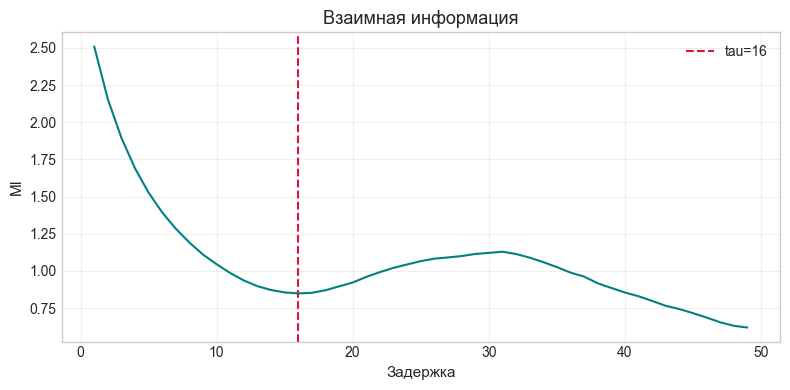

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(mi)+1), mi, color="teal", linewidth=1.5)
ax.axvline(x=first_min, color="crimson", linestyle="--", label=f"tau={first_min}")
ax.set_title("Взаимная информация", fontsize=13)
ax.set_xlabel("Задержка", fontsize=11)
ax.set_ylabel("MI", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Прогнозирование хаотического ряда

In [13]:
tau = first_min
dim = 3

def embed_delay(x, tau, dim):
    n = len(x) - (dim - 1) * tau
    X = np.zeros((n, dim))
    for i in range(dim):
        X[:, i] = x[i*tau : i*tau + n]
    return X

X_emb = embed_delay(x_data, tau, dim)
# Целевой вектор: следующее значение после последнего измерения в каждом окне
y_target = x_data[(dim - 1) * tau + 1 : len(X_emb) + (dim - 1) * tau + 1]
# Выровнять длины
min_len = min(len(X_emb), len(y_target))
X_emb    = X_emb[:min_len]
y_target = y_target[:min_len]

X_train = X_emb[:-100]
y_train = y_target[:-100]
X_test  = X_emb[-100:]
y_test  = y_target[-100:]

print(f"Размерность вложения: {dim}, задержка: {tau}")
print(f"Обучение: {X_train.shape}, Тест: {X_test.shape}")
print(f"len y_train: {len(y_train)}, len y_test: {len(y_test)}")

Размерность вложения: 3, задержка: 16
Обучение: (4867, 3), Тест: (100, 3)
len y_train: 4867, len y_test: 100


In [14]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge MSE: {mse_ridge:.6f}")

Ridge MSE: 0.043539


In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"RandomForest MSE: {mse_rf:.6f}")

RandomForest MSE: 0.000965


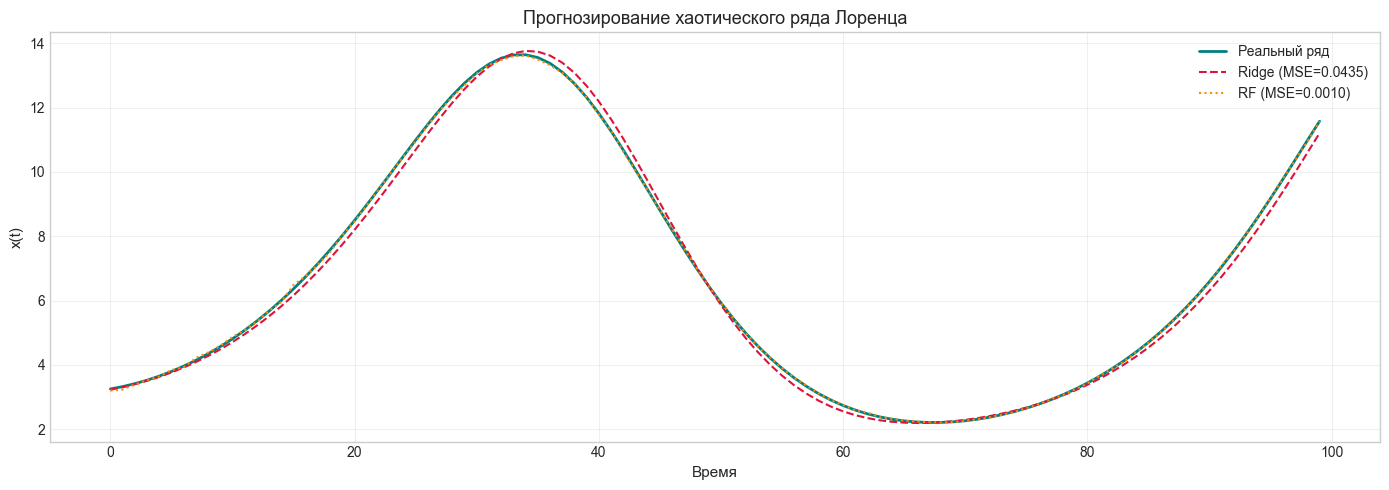

In [16]:
n_plot = min(100, len(y_test))
t_plot = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_plot, y_test[:n_plot], "teal", lw=2, label="Реальный ряд")
ax.plot(t_plot, y_pred_ridge[:n_plot], "crimson", lw=1.5, linestyle="--",
        label=f"Ridge (MSE={mse_ridge:.4f})")
ax.plot(t_plot, y_pred_rf[:n_plot], "darkorange", lw=1.5, linestyle=":",
        label=f"RF (MSE={mse_rf:.4f})")
ax.set_title("Прогнозирование хаотического ряда Лоренца", fontsize=13)
ax.set_xlabel("Время", fontsize=11)
ax.set_ylabel("x(t)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ridge показал MSE = 0.0435, RandomForest  MSE = 0.0010. RF превосходит Ridge в ~45 раз за счёт способности моделировать нелинейные зависимости хаотического ряда.

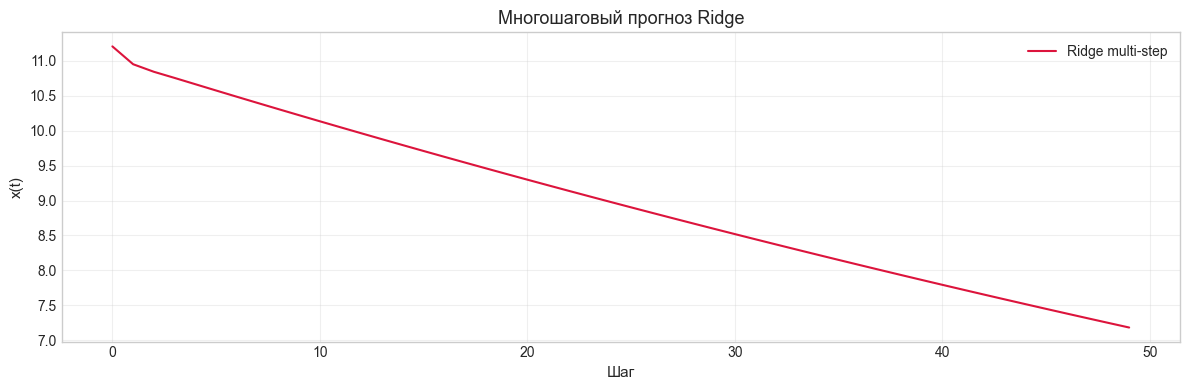

In [17]:
horizon = 50
# Начинаем с последнего окна тест-выборки (dim точек)
x0_forecast = list(X_test[-1])

pred_ridge_multi = list(x0_forecast)
for _ in range(horizon):
    x_input = np.array(pred_ridge_multi[-dim:]).reshape(1, -1)
    next_val = ridge.predict(x_input)[0]
    pred_ridge_multi.append(next_val)

pred_ridge_multi = pred_ridge_multi[dim:]  # только прогноз

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(horizon), pred_ridge_multi, "crimson", lw=1.5, label="Ridge multi-step")
ax.set_title("Многошаговый прогноз Ridge", fontsize=13)
ax.set_xlabel("Шаг", fontsize=11)
ax.set_ylabel("x(t)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Многошаговый прогноз расходится с реальным рядом из-за хаотической природы системы. Ошибка накапливается экспоненциально.